In [5]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb.model import GRSC_CB_Model
from grsc_cb.instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# number of land parcels
n = 400
# number of species
m = 20
# number of max connected areas
k = 2
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1
# tau threshold
tau = 0.8

External nodes: {np.int32(352), np.int32(320), np.int32(357), np.int32(325), np.int32(201), np.int32(42), np.int32(332), np.int32(211), np.int32(180), np.int32(309), np.int32(373), np.int32(121), np.int32(123), np.int32(60)}


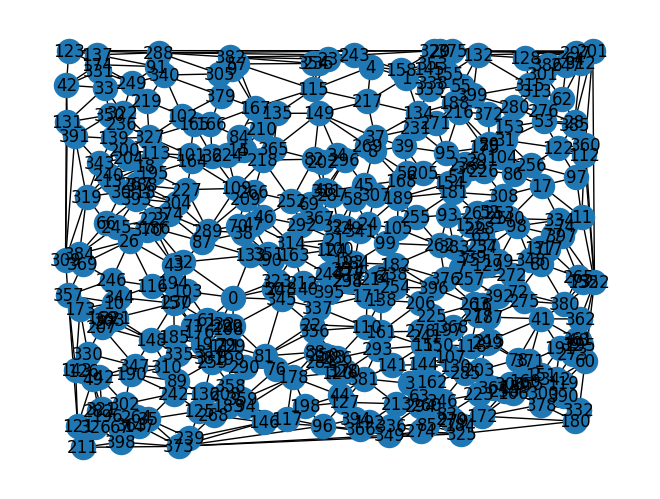

In [7]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, h = simplex
    G.add_edge(i, j)
    G.add_edge(j, h)
    G.add_edge(i, h)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {external_nodes}")

In [8]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [9]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2)

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

In [10]:
# toy instance
V, E = set(G.nodes), set(G.edges)
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, tau, d)

instance.draw_graph()


GRSC_CB_Instance(|V|=400, |E|=1183, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter Username
Set parameter LicenseID to value 2796100
Academic license - for non-commercial use only - expires 2027-03-23
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 81.0
Nodes in the reserve (x): [28, 49, 66, 72, 74, 103, 140, 153, 157, 159, 174, 209, 220, 225, 235, 253, 261, 275, 304, 331, 356, 365, 388]
Nodes in the core (z): [28, 49, 66, 72, 74, 103, 140, 153, 157, 159, 174, 209, 220, 225, 235, 253, 261, 275, 304, 331, 356, 365, 388]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): []


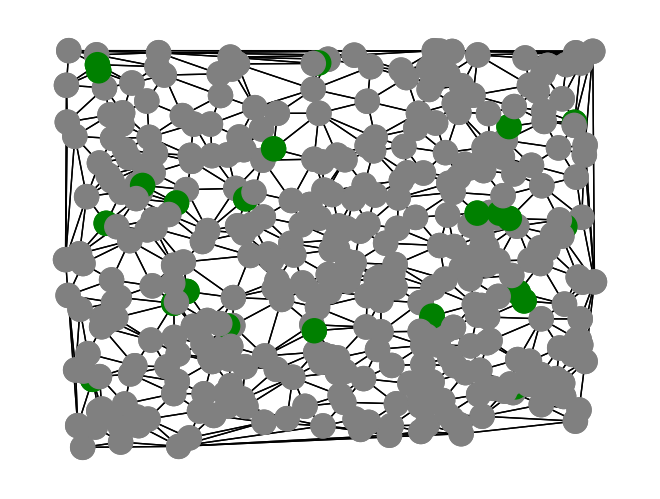

In [11]:
print(instance)
model = GRSC_CB_Model(instance, B=False, C=False)
model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1183, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 1317.0
Nodes in the reserve (x): [1, 28, 29, 31, 53, 55, 62, 64, 122, 128, 132, 145, 153, 155, 158, 201, 247, 276, 280, 297, 301, 312, 313, 315, 320, 333, 338, 353, 360, 372, 375, 385, 386, 399]
Nodes in the core (z): [28, 53, 62, 64, 128, 145, 155, 247, 276, 280, 297, 301, 312, 313, 315, 338, 353, 375, 385, 386]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): []


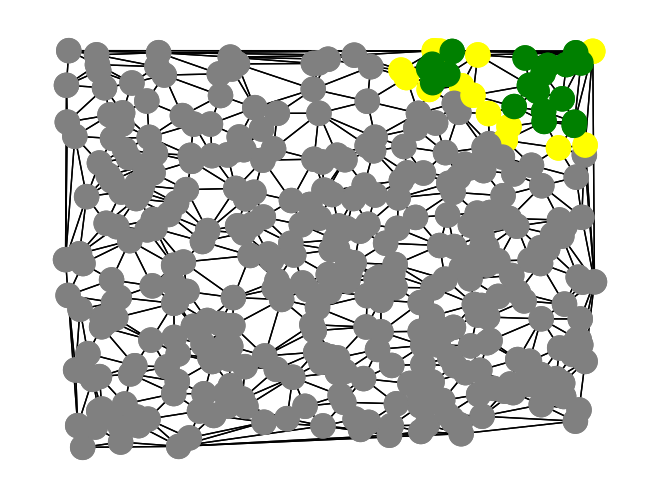

In [12]:
print(instance)
model = GRSC_CB_Model(instance, C=False)
model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1183, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 325, 'corecon-frc': 0, 'cover-s1': 282, 'cover-s2': 195, 'scc': 0}
Status: 2 Optimal
Objective: 437.0
Nodes in the reserve (x): [1, 11, 17, 25, 65, 74, 75, 86, 115, 134, 140, 145, 155, 158, 167, 217, 226, 235, 243, 253, 382, 383, 389]
Nodes in the core (z): [1, 11, 17, 25, 65, 74, 75, 86, 115, 134, 140, 145, 155, 158, 167, 217, 226, 235, 243, 253, 382, 383, 389]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): [1, 11]


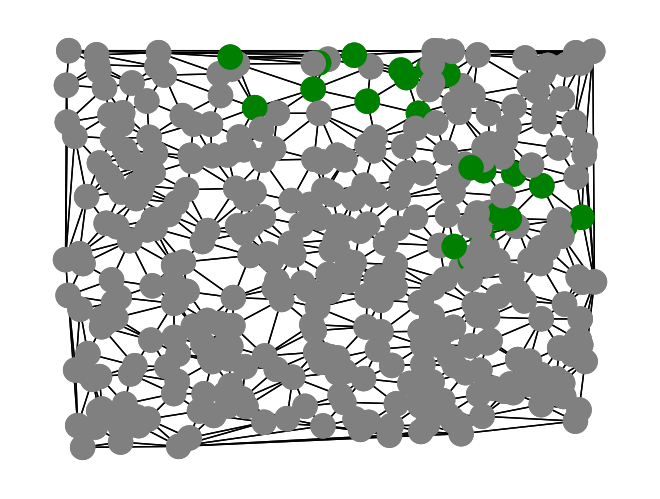

In [13]:
print(instance)
model = GRSC_CB_Model(instance, B=False)
model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1183, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 146, 'corecon-frc': 0, 'cover-s1': 7, 'cover-s2': 0, 'scc': 0}
Status: 2 Optimal
Objective: 1321.0
Nodes in the reserve (x): [11, 17, 20, 28, 31, 53, 62, 64, 97, 112, 122, 128, 132, 153, 201, 216, 247, 256, 276, 280, 297, 301, 312, 313, 315, 352, 360, 372, 385, 386, 399]
Nodes in the core (z): [28, 53, 62, 64, 97, 112, 122, 128, 153, 247, 276, 280, 301, 312, 313, 315, 360, 372, 385, 386]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): [28, 64]


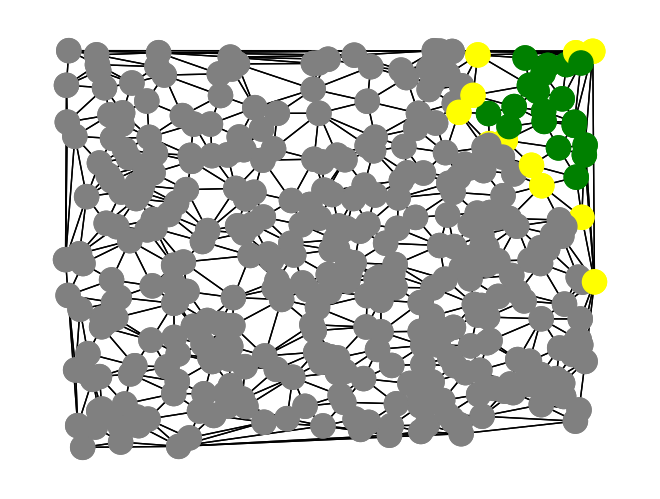

In [14]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1183, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting construction heuristic...
	 * Initial solution found with Construction Heuristic. Nodes: {0, 1, 2, 257, 6, 7, 8, 262, 263, 269, 271, 16, 17, 277, 22, 24, 25, 284, 37, 39, 40, 41, 296, 298, 299, 45, 50, 306, 307, 308, 56, 65, 75, 333, 78, 334, 81, 337, 339, 345, 92, 93, 98, 99, 355, 105, 110, 368, 371, 118, 376, 377, 383, 134, 392, 138, 395, 140, 396, 149, 154, 156, 159, 160, 168, 171, 181, 182, 187, 188, 189, 205, 214, 215, 217, 225, 231, 234, 237, 238, 248, 253, 254, 255}
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 141, 'corecon-frc': 0, 'cover-s1': 68, 'cover-s2': 0, 'scc': 0}
Status: 2 Optimal
Objective: 1317.0
Nodes in the reserve (x): [1, 28, 29, 31, 53, 55, 62, 64, 122, 128, 132, 145, 153, 155, 158, 201, 247, 276, 280, 297, 301, 312, 313, 315, 320, 333, 338, 353, 360, 372, 375, 385, 386, 399]
Nodes in the core (z): [28, 5

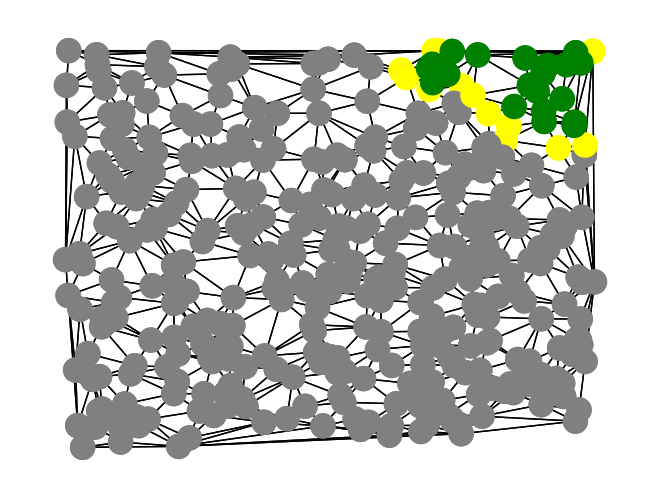

In [15]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True)
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1183, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting construction heuristic...
	 * Initial solution found with Construction Heuristic. Nodes: {0, 1, 2, 4, 13, 23, 26, 29, 30, 32, 33, 42, 43, 50, 61, 66, 83, 85, 87, 92, 103, 106, 115, 116, 123, 131, 133, 134, 137, 145, 151, 158, 159, 160, 172, 174, 180, 184, 186, 194, 201, 217, 222, 223, 232, 240, 243, 245, 258, 260, 270, 274, 279, 288, 294, 300, 309, 319, 320, 323, 325, 331, 333, 336, 338, 343, 345, 353, 355, 357, 369, 370, 371, 375, 378, 384, 391, 393}
	 * Starting local branching heuristic...
	 * Added constraints: {'corecon-int': 30, 'corecon-frc': 0, 'cover-s1': 2, 'cover-s2': 0, 'scc': 0}
	 * Added constraints: {'corecon-int': 3, 'corecon-frc': 0, 'cover-s1': 44, 'cover-s2': 0, 'scc': 0}
	 * Added constraints: {'corecon-int': 5, 'corecon-frc': 0, 'cover-s1': 20, 'cover-s2': 0, 'scc': 0}
	 * Added constraints: {'corecon-int': 2, 'corecon-frc': 0, 'cover-s1

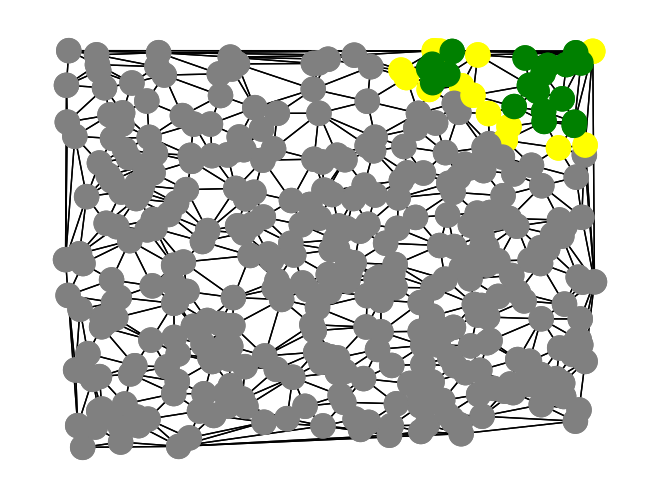

In [16]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True, lb_heuristic=True)
model.print_solution()